# Reproduce unsupervised Figures 6-8: density PCA example

This notebook reproduces the illustrative unsupervised PCA example from the density/oil-fraction section of the paper. The example has two real, correlated variables and one added `Random Normal` Synthetic Noise Feature (SNF). The PCA model is recomputed in Python with `pyphi-mvda`, while the supplied Excel exports are used as numerical checks against the JMP analysis.

## Reference and library

**Main article:** Vallerio, M., del Rio Chanona, A., & Navarro-Brull, F. J. (2026). *All you need is noise - from feature selection to explainable industrial AI*. **Digital Chemical Engineering, 18**, 100290. https://doi.org/10.1016/j.dche.2026.100290

**PCA library used:** this notebook fits PCA models with `pyphi-mvda`, the Python MVDA library from Salvador Garcia Munoz: https://github.com/salvadorgarciamunoz/pyphi. The package is imported as `from pyphi import calc as phi`, and PCA is fitted with `phi.pca(...)` using autoscaling (`mcs=True`) to match JMP's PCA-on-correlations workflow.

**Paper idea reproduced here:** the article adds a Synthetic Noise Feature (SNF) to the variable set before fitting PCA. Principal components are retained only until the first component where the SNF becomes the dominant loading. Components at and after that point are treated as carrying no more structured information than injected noise.

In [1]:
# Self-contained runtime setup for reproducing the paper figures.
import importlib.util
import subprocess
import sys


def ensure(import_name, package_name=None):
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


for import_name, package_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("openpyxl", "openpyxl"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scipy", "scipy"),
    ("pyphi", "pyphi-mvda"),
]:
    ensure(import_name, package_name)

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyphi import calc as phi

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.92)


def find_unsupervised_root():
    """Locate the 02_unsupervised folder from this notebook or current working directory."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    fallback = Path("/Users/b42549592/Documents/GitHub/all-you-need-is-noise/02_unsupervised")
    candidates.extend([fallback, *fallback.parents])
    for candidate in candidates:
        if candidate.name == "02_unsupervised" and (candidate / "01_density_dataset").exists() and (candidate / "02_TEP").exists():
            return candidate
        nested = candidate / "02_unsupervised"
        if (nested / "01_density_dataset").exists() and (nested / "02_TEP").exists():
            return nested
    raise FileNotFoundError("Could not locate the 02_unsupervised folder")


UNSUPERVISED_ROOT = find_unsupervised_root()

PALETTE = {
    "real_1": "#1f77b4",
    "real_2": "#111111",
    "noise": "#d62728",
    "pc1": "#1f77b4",
    "pc2": "#d62728",
    "pc3": "#2ca02c",
    "pc4": "#9467bd",
    "pc5": "#ff7f0e",
}


def pca_with_pyphi(data, obs_col, feature_cols, n_components):
    """Fit pyphi PCA and return scores, loadings, and explained variance tables."""
    X = pd.concat([
        data[obs_col].astype(str).rename("obs"),
        data[feature_cols].apply(pd.to_numeric, errors="coerce"),
    ], axis=1)
    model = phi.pca(X, n_components, mcs=True, force_nipals=True, shush=True)
    pc_names = [f"PC{i}" for i in range(1, n_components + 1)]
    scores = pd.DataFrame(model["T"], columns=pc_names, index=data.index)
    loadings = pd.DataFrame(model["P"], index=model["varidX"], columns=pc_names)
    explained = pd.DataFrame({
        "PC": pc_names,
        "explained_percent": np.asarray(model["r2x"])[:n_components] * 100,
    })
    explained["cumulative_percent"] = explained["explained_percent"].cumsum()
    return model, scores, loadings, explained

Will be using the NEOS server in the absence of IPOPT and GAMS


In [3]:
DATA_PATH = UNSUPERVISED_ROOT / "01_density_dataset" / "density_PCA_simple_explanation.xlsx"
LOADINGS_EXPORT = UNSUPERVISED_ROOT / "01_density_dataset" / "results" / "densitiy_PCs_loadings_noise_explanation.xlsx"
VAR_LOADINGS_EXPORT = UNSUPERVISED_ROOT / "01_density_dataset" / "results" / "densitiy_var_PCs_loadings_noise_explanation.xlsx"
PARTIAL_EXPORT = UNSUPERVISED_ROOT / "01_density_dataset" / "results" / "denisity_partial_plot_contribution.xlsx"

raw = pd.read_excel(DATA_PATH)
exported_pc = pd.read_excel(LOADINGS_EXPORT)
exported_var_loadings = pd.read_excel(VAR_LOADINGS_EXPORT)
partial_contribution = pd.read_excel(PARTIAL_EXPORT)

feature_cols = ["Oil fraction [%]", "Density [kg/m^3]", "Random Normal"]
model, scores, loadings, explained = pca_with_pyphi(raw, "Run", feature_cols, 3)
# JMP plots the PCA loading matrix as eigenvectors scaled by sqrt(eigenvalue).
eigenvalues = explained["explained_percent"].to_numpy() / 100 * len(feature_cols)
loading_matrix = loadings.multiply(np.sqrt(eigenvalues), axis=1)
abs_loadings = loading_matrix.abs()

print(f"Loaded {len(raw)} density observations")
display(raw.head())
display(explained.round(3))

Loaded 51 density observations


,Run,Oil fraction [%],Density [kg/m^3],Random Normal,Random Uniform,Prin1,Prin2,Prin3
0,1,16.54,2955.0,-0.485101,0.155120,0.813137,-0.403330,0.383471
1,2,17.76,2655.9,-1.416154,0.746649,-1.404704,-1.437931,-0.505147
2,3,16.22,2867.5,-0.347134,0.331605,0.478093,-0.380616,-0.250065
3,4,16.74,2920.4,-0.429211,0.520658,0.540947,-0.354386,0.269444
4,5,16.33,2975.7,0.506473,0.122844,1.074623,0.569588,0.188965


,PC,explained_percent,cumulative_percent
0,PC1,53.892,53.892
1,PC2,34.323,88.215
2,PC3,11.785,100.000


## Validation against exported PCA results

PCA loading signs can flip without changing the model. The checks therefore compare absolute loadings and explained-variance percentages.

In [4]:
# Compare pyphi's PCA outputs against the supplied JMP/Excel export.
# PCA signs are arbitrary, so the validation uses absolute loading magnitudes.
export_abs = exported_pc.set_index("Principal Component")[[
    "Abs[Oil fraction [%]]", "Abs[Density [kg/m^3]]", "Abs[Random Normal]"
]].copy()
export_abs.columns = feature_cols
pyphi_abs = abs_loadings.T
pyphi_abs.index.name = "Principal Component"

# Explained variance should match exactly; loading-matrix values should match
# after scaling pyphi eigenvectors by sqrt(eigenvalue), as JMP displays them.
loading_delta = (pyphi_abs - export_abs).abs()
variance_delta = (
    explained.set_index("PC")["explained_percent"]
    - exported_pc.set_index("Principal Component")["Percent"]
).abs()

print("Maximum absolute-loading delta vs Excel export:", loading_delta.to_numpy().max().round(8))
print("Maximum explained-variance delta vs Excel export:", variance_delta.max().round(8))
assert loading_delta.to_numpy().max() < 1e-3
assert variance_delta.max() < 1e-6

Maximum absolute-loading delta vs Excel export: 1.863e-05
Maximum explained-variance delta vs Excel export: 1e-08


## Figure 6: density data, synthetic noise, and PC directions

**Article explanation:** Figure 6 introduces the illustrative dataset used to explain SNF-guided dimensionality reduction. Oil fraction and density move coherently, while the added random-normal feature behaves like unstructured white noise. The scatter plot shows that the two real variables are strongly correlated, so the first principal component captures their shared variation.

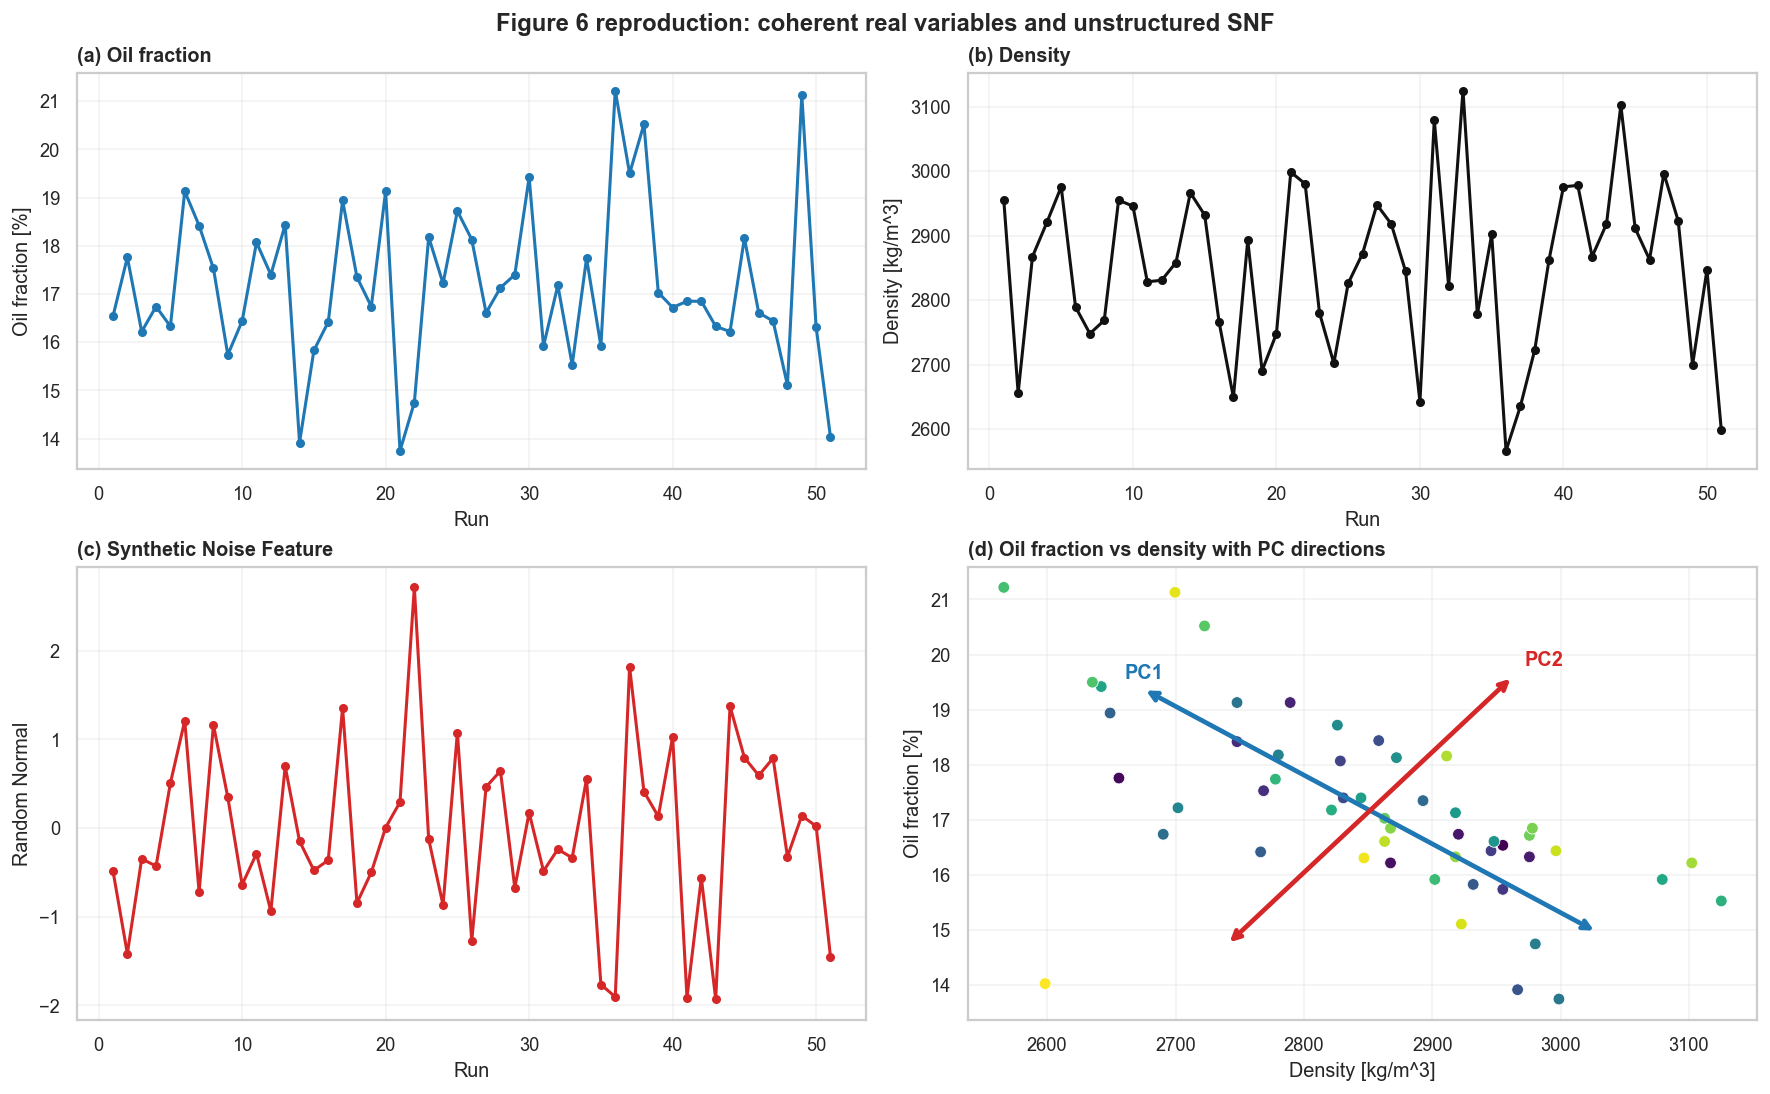

In [5]:
# Build a four-panel layout matching the paper: three traces plus one scatter plot.
fig = plt.figure(figsize=(13.5, 8.3), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.2])
trace_axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
trace_axes.append(fig.add_subplot(gs[1, 0]))
scatter_ax = fig.add_subplot(gs[1, 1])

# Plot the two real variables and the synthetic noise feature across run number.
trace_specs = [
    ("Oil fraction [%]", "(a) Oil fraction", PALETTE["real_1"]),
    ("Density [kg/m^3]", "(b) Density", PALETTE["real_2"]),
    ("Random Normal", "(c) Synthetic Noise Feature", PALETTE["noise"]),
]
for ax, (col, title, color) in zip(trace_axes, trace_specs):
    ax.plot(raw["Run"], raw[col], color=color, lw=1.7)
    ax.scatter(raw["Run"], raw[col], color=color, s=16, zorder=3)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Run")
    ax.set_ylabel(col)

# Show the correlation between the two real variables and overlay PC directions.
x = raw["Density [kg/m^3]"]
y = raw["Oil fraction [%]"]
scatter_ax.scatter(x, y, c=raw["Run"], cmap="viridis", s=42, edgecolor="white", linewidth=0.45)
scatter_ax.set_title("(d) Oil fraction vs density with PC directions", loc="left", fontweight="bold")
scatter_ax.set_xlabel("Density [kg/m^3]")
scatter_ax.set_ylabel("Oil fraction [%]")

center = np.array([x.mean(), y.mean()])
scale = np.array([x.std(ddof=1), y.std(ddof=1)])
for pc, color, label, length in [("PC1", PALETTE["pc1"], "PC1", 2.7), ("PC2", PALETTE["pc2"], "PC2", 1.7)]:
    # Convert autoscaled PCA directions back into the original data units.
    direction = loadings.loc[["Density [kg/m^3]", "Oil fraction [%]"], pc].to_numpy() * scale
    direction = direction / np.linalg.norm(direction)
    vector = direction * np.array([x.std(ddof=1), y.std(ddof=1)]).mean() * length
    scatter_ax.annotate("", xy=center + vector, xytext=center - vector,
                        arrowprops=dict(arrowstyle="<->", lw=2.6, color=color))
    text_xy = center + vector * 1.08
    scatter_ax.text(text_xy[0], text_xy[1], label, color=color, fontweight="bold")

fig.suptitle("Figure 6 reproduction: coherent real variables and unstructured SNF", fontweight="bold")
plt.show()

**Figure 6 caption.** Control charts show the noise trace as unstructured white noise, whereas oil fraction and density move coherently. Panels (a)-(c) show oil fraction, density, and the Synthetic Noise Feature (SNF). Panel (d) shows oil fraction versus density and overlays PC1 and PC2 directions.

## Figure 7: absolute loadings and explained variance

**Article explanation:** Figure 7 shows that PC1 has large loadings for the two real variables and low loading for the SNF, explaining about 53.9% of the variance. PC2 is dominated by the SNF and explains about 34.3%, so the article's rule keeps PC1 and discards PC2 and later components.

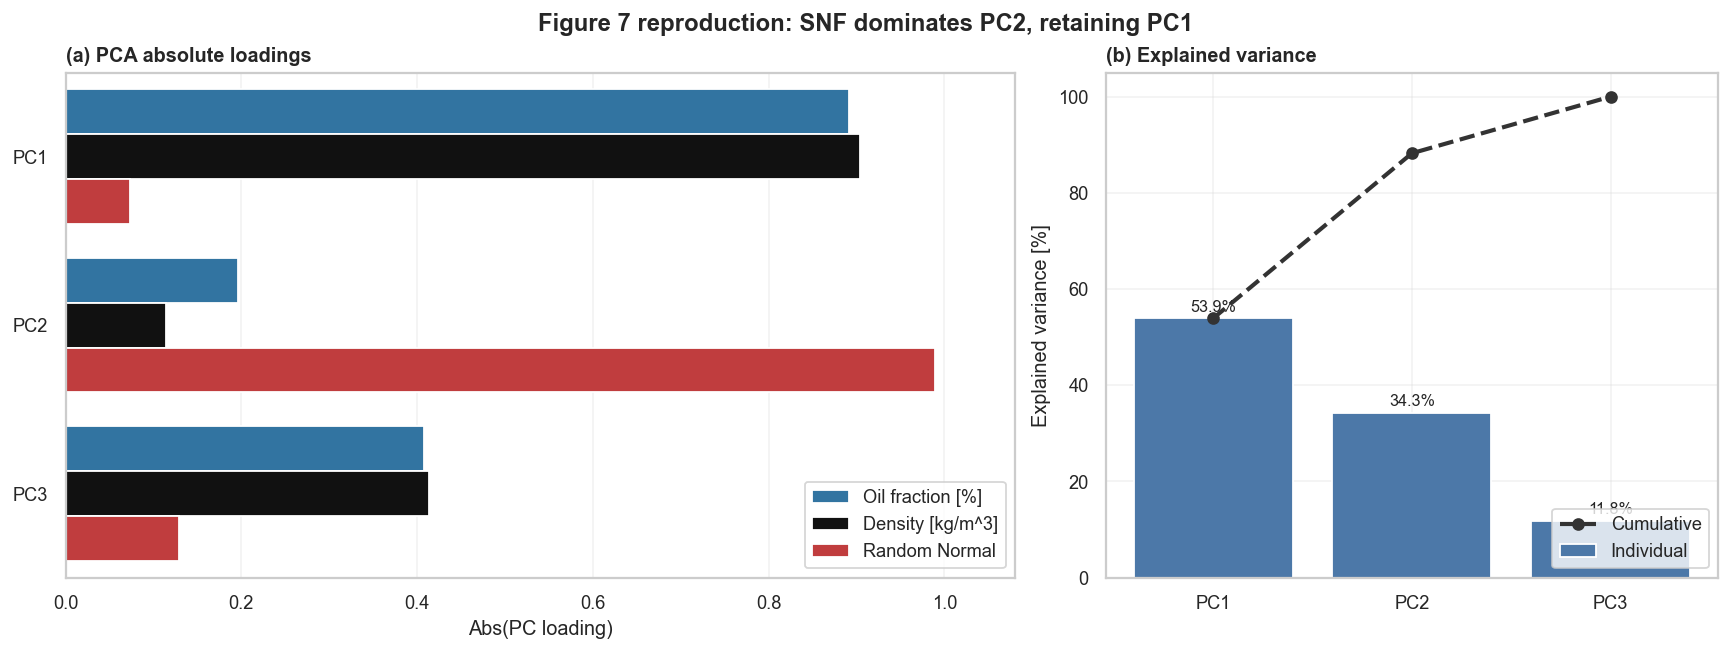

In [6]:
# Panel (a): reshape absolute loadings into long form for grouped horizontal bars.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.9), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.55, 1.0]})

long_loadings = abs_loadings.reset_index(names="Variable").melt(
    id_vars="Variable", var_name="PC", value_name="Abs loading"
)
sns.barplot(data=long_loadings, y="PC", x="Abs loading", hue="Variable", ax=axes[0],
            palette=[PALETTE["real_1"], PALETTE["real_2"], PALETTE["noise"]], orient="h")
axes[0].set_title("(a) PCA absolute loadings", loc="left", fontweight="bold")
axes[0].set_xlabel("Abs(PC loading)")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 1.08)
axes[0].legend(loc="lower right", frameon=True, title="")

# Panel (b): plot individual variance bars and cumulative variance line.
xpos = np.arange(len(explained))
axes[1].bar(xpos, explained["explained_percent"], color="#4c78a8", label="Individual")
axes[1].plot(xpos, explained["cumulative_percent"], color="#333333", marker="o", lw=2.3,
             linestyle="--", label="Cumulative")
for x_i, pct in zip(xpos, explained["explained_percent"]):
    axes[1].text(x_i, pct + 1.4, f"{pct:.1f}%", ha="center", fontsize=9)
axes[1].set_xticks(xpos, explained["PC"])
axes[1].set_ylim(0, 105)
axes[1].set_ylabel("Explained variance [%]")
axes[1].set_title("(b) Explained variance", loc="left", fontweight="bold")
axes[1].legend(loc="lower right", frameon=True)

fig.suptitle("Figure 7 reproduction: SNF dominates PC2, retaining PC1", fontweight="bold")
plt.show()

**Figure 7 caption.** Absolute loadings show that the synthetic-noise feature dominates PC2, signaling that only the noise-free PC1 should be retained. Panel (a) shows PCA absolute loadings across the first three principal components; panel (b) shows individual and cumulative explained variance.

## Figure 8: cumulative absolute loadings by variable

**Article explanation:** Figure 8 restates the Figure 7 conclusion in variable space. Stacked cumulative loadings show how much each PC contributes to each variable. The SNF receives most of its loading from PC2, while the real variables are primarily represented by PC1.

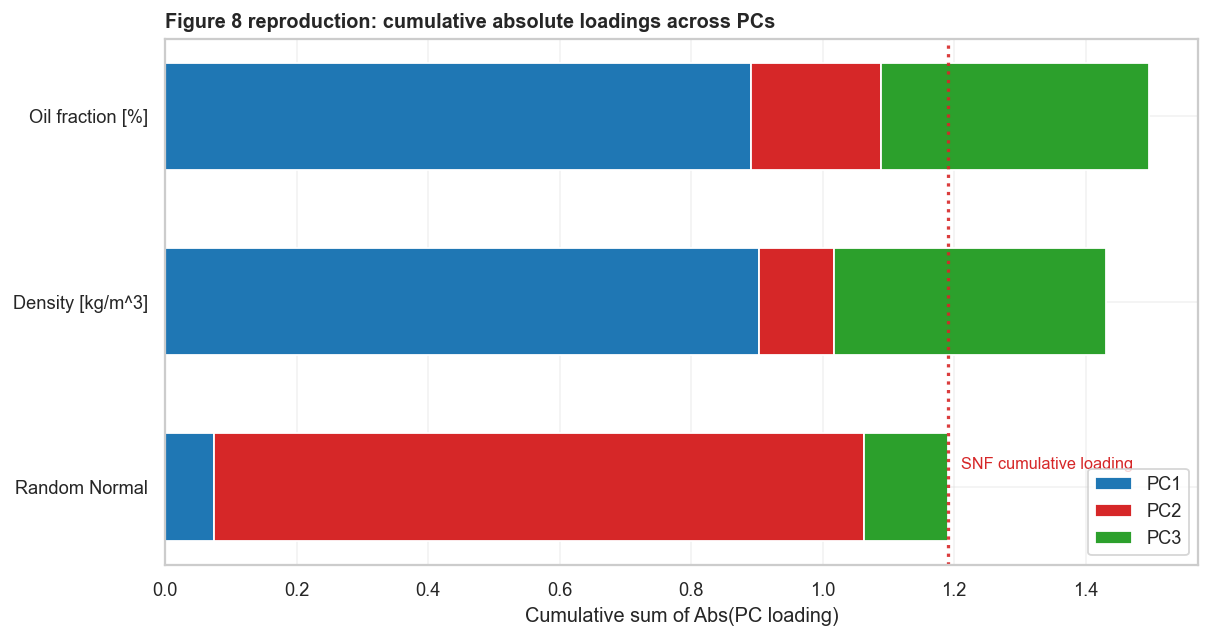

In [7]:
# Sum absolute loadings by variable and stack PC contributions horizontally.
stacked = abs_loadings[["PC1", "PC2", "PC3"]].copy()
stacked["total"] = stacked.sum(axis=1)
stacked = stacked.sort_values("total", ascending=True).drop(columns="total")

fig, ax = plt.subplots(figsize=(9.2, 4.8), constrained_layout=True)
left = np.zeros(len(stacked))
pc_colors = [PALETTE["pc1"], PALETTE["pc2"], PALETTE["pc3"]]
for pc, color in zip(stacked.columns, pc_colors):
    ax.barh(stacked.index, stacked[pc], left=left, label=pc, color=color, height=0.58)
    left += stacked[pc].to_numpy()

# Mark the SNF cumulative loading as a visual cutoff reference.
noise_total = stacked.loc["Random Normal"].sum()
ax.axvline(noise_total, color=PALETTE["noise"], lw=1.8, linestyle=":", alpha=0.9)
ax.text(noise_total + 0.02, 0.1, "SNF cumulative loading", color=PALETTE["noise"], fontsize=9)
ax.set_xlabel("Cumulative sum of Abs(PC loading)")
ax.set_ylabel("")
ax.set_title("Figure 8 reproduction: cumulative absolute loadings across PCs", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=True, title="")
plt.show()

**Figure 8 caption.** Stacked cumulative loadings show that PCs 2 and 3 are driven largely by the synthetic-noise feature, confirming that only PC1 carries the real signal under the SNF cutoff. Bar segments are color-coded by contributing PC.

## Partial contribution export

This table is not required for the three plotted figures, but is included to keep the notebook close to the attached JMP/Excel PCA outputs.

In [8]:
display(partial_contribution.round(3))

,Variable,PC1,PC2,PC3
0,Oil fraction [%],49.164,3.758,47.078
1,Density [kg/m^3],50.503,1.257,48.240
2,Random Normal,0.333,94.985,4.682
